In [1]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import RandomOverSampler
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

train = pd.read_csv("/Users/nicholascullen/Documents/heartdisease_train-1.csv")
test = pd.read_csv("/Users/nicholascullen/Documents/heartdisease_test-1.csv")

In [2]:
train['BMI'].fillna(train['BMI'].mean(), inplace=True)
test['BMI'].fillna(train['BMI'].mean(), inplace=True)

/var/folders/84/nq6m_5w937ddt23mzpd0k9h40000gn/T/ipykernel_33137/1365990233.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['BMI'].fillna(train['BMI'].mean(), inplace=True)
/var/folders/84/nq6m_5w937ddt23mzpd0k9h40000gn/T/ipykernel_33137/1365990233.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [3]:
X = train.drop('TenYearCHD', axis=1)
y = train['TenYearCHD']

ros = RandomOverSampler(random_state=1)
X_res, y_res = ros.fit_resample(X, y)

In [4]:
X_res_const = sm.add_constant(X_res)

model = sm.Logit(y_res, X_res_const).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.600174
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 6182
Model:                          Logit   Df Residuals:                     6167
Method:                           MLE   Df Model:                           14
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.1341
Time:                        11:46:40   Log-Likelihood:                -3710.3
converged:                       True   LL-Null:                       -4285.0
Covariance Type:            nonrobust   LLR p-value:                1.228e-236
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.5950      0.397    -16.606      0.000      -7.373      -5.817
gender        

In [5]:
significant_vars = model.pvalues[model.pvalues < 0.05].index
significant_vars = significant_vars.drop('const')

X_res_final = X_res[significant_vars]
X_res_final = sm.add_constant(X_res_final)

final_model = sm.Logit(y_res, X_res_final).fit()
print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.600996
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 6182
Model:                          Logit   Df Residuals:                     6172
Method:                           MLE   Df Model:                            9
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.1329
Time:                        11:46:40   Log-Likelihood:                -3715.4
converged:                       True   LL-Null:                       -4285.0
Covariance Type:            nonrobust   LLR p-value:                1.495e-239
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -6.5441      0.331    -19.785      0.000      -7.192      -5.896
gender           0.5782

In [6]:
coef = final_model.params['cigsPerDay']
odds_ratio = np.exp(coef)

print("Coefficient:", coef)
print("Odds Ratio:", odds_ratio)

Coefficient: 0.02143690424419497
Odds Ratio: 1.0216683253684993


In [7]:
X_test = test[significant_vars]
X_test = sm.add_constant(X_test)

y_pred_prob = final_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

In [8]:
cm = confusion_matrix(test['TenYearCHD'], y_pred)
print(cm)

[[6 2]
 [0 2]]


In [9]:
accuracy = metrics.accuracy_score(test['TenYearCHD'], y_pred)
precision = metrics.precision_score(test['TenYearCHD'], y_pred)
recall = metrics.recall_score(test['TenYearCHD'], y_pred)
f1 = metrics.f1_score(test['TenYearCHD'], y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8
Precision: 0.5
Recall: 1.0
F1 Score: 0.6666666666666666


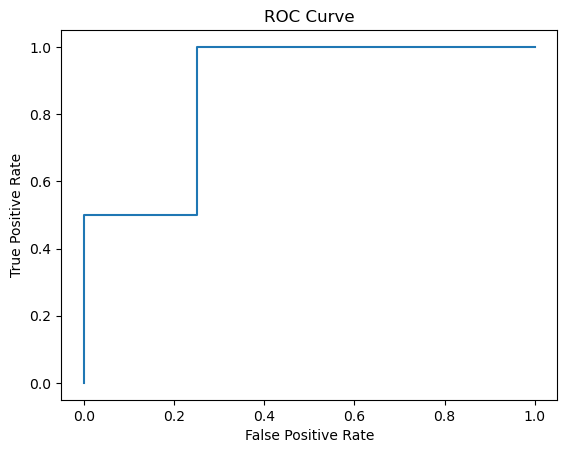

AUC: 0.875


In [10]:
fpr, tpr, thresholds = roc_curve(test['TenYearCHD'], y_pred_prob)
auc_score = roc_auc_score(test['TenYearCHD'], y_pred_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", auc_score)